# DC3DMN - Lab 6

## Objectives
- Use your recently acquired knowledge of practical Data Mining for a small project.

## Suggested Reading
Past lab tasks (incl. model solutions, if needed) 

*****

## Brief description
In this lab you'll fit a **classification** model to predict whether an individual will develop diabetes, based on some characteristics of that person. For that, you'll use a subset of a famous dataset known as the Pima Indian Diabetes Dataset (PIDD). This subset of data (file *diabetes.csv* available on BB) consists of a number of observations related to women of Pima Indian heritage, aged 21 and above. Your task is to build a model capable of predicting the onset of diabetes (variable `Outcome`) based on the other variables in the data set.

The diabetes dataset contains the following columns:

1. Number of times pregnant
2. Plasma glucose concentration a 2 hours in an oral glucose tolerance test
3. Diastolic blood pressure (mm Hg)
4. Triceps skin fold thickness (mm)
5. 2-Hour serum insulin (mu U/ml)
6. Body mass index [(weight in kg)/(height in m)<sup>2</sup>]
7. Diabetes pedigree function
8. Age (in years)
9. Outcome (Class variable - 0 or 1)


**TO DO**
- Load the diabetes dataset
- Explore the dataset using summary statistics: how many rows, how many columns, scale (range of values) in each column, presence or not of missing values, class balance (number of observations from each class)
- Use function `pairplot()` from library Seaborn to generate a correlation plot. Set option `hue = 'Outcome'` to colour the plot by the outcome variable. Check this plot to make sure there isn't anything unusual in the data.
    - Note: Some variables may not have missing data, but values that are impossible. Check the plot for that! For instance, is it possible for a person to have a body mass index (BMI) of zero? Or a blood pressure of zero? Use your common sense and apply listwise deletion (removal of rows) where these impossible values happen.
- Split the data into a training (75%) and a test split (25%), _keeping the class balance within each split_. The easiest way to do that is using function `train_test_split()`, imported from *sklearn.model_selection*, and using option `stratify = your_target_variable` (replace `your_target_variable` by the name of your target variable).
- Fit a **Random Forest** classifier (remember, you did this in Lab 5).
- Use your test split to assess the performance of your classifier. Use the *f1_score* (imported from _sklearn.metrics_) to evaluate model quality.

In [12]:
import pandas as pd
import numpy as np
import seaborn as sns
import sklearn.model_selection as ms
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score

#Carry out read of data

df_all = pd.read_csv("diabetes.csv")
print(f"All shape is: {df_all.shape}")
df_all.head()
df_all.dtypes

All shape is: (768, 9)


Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

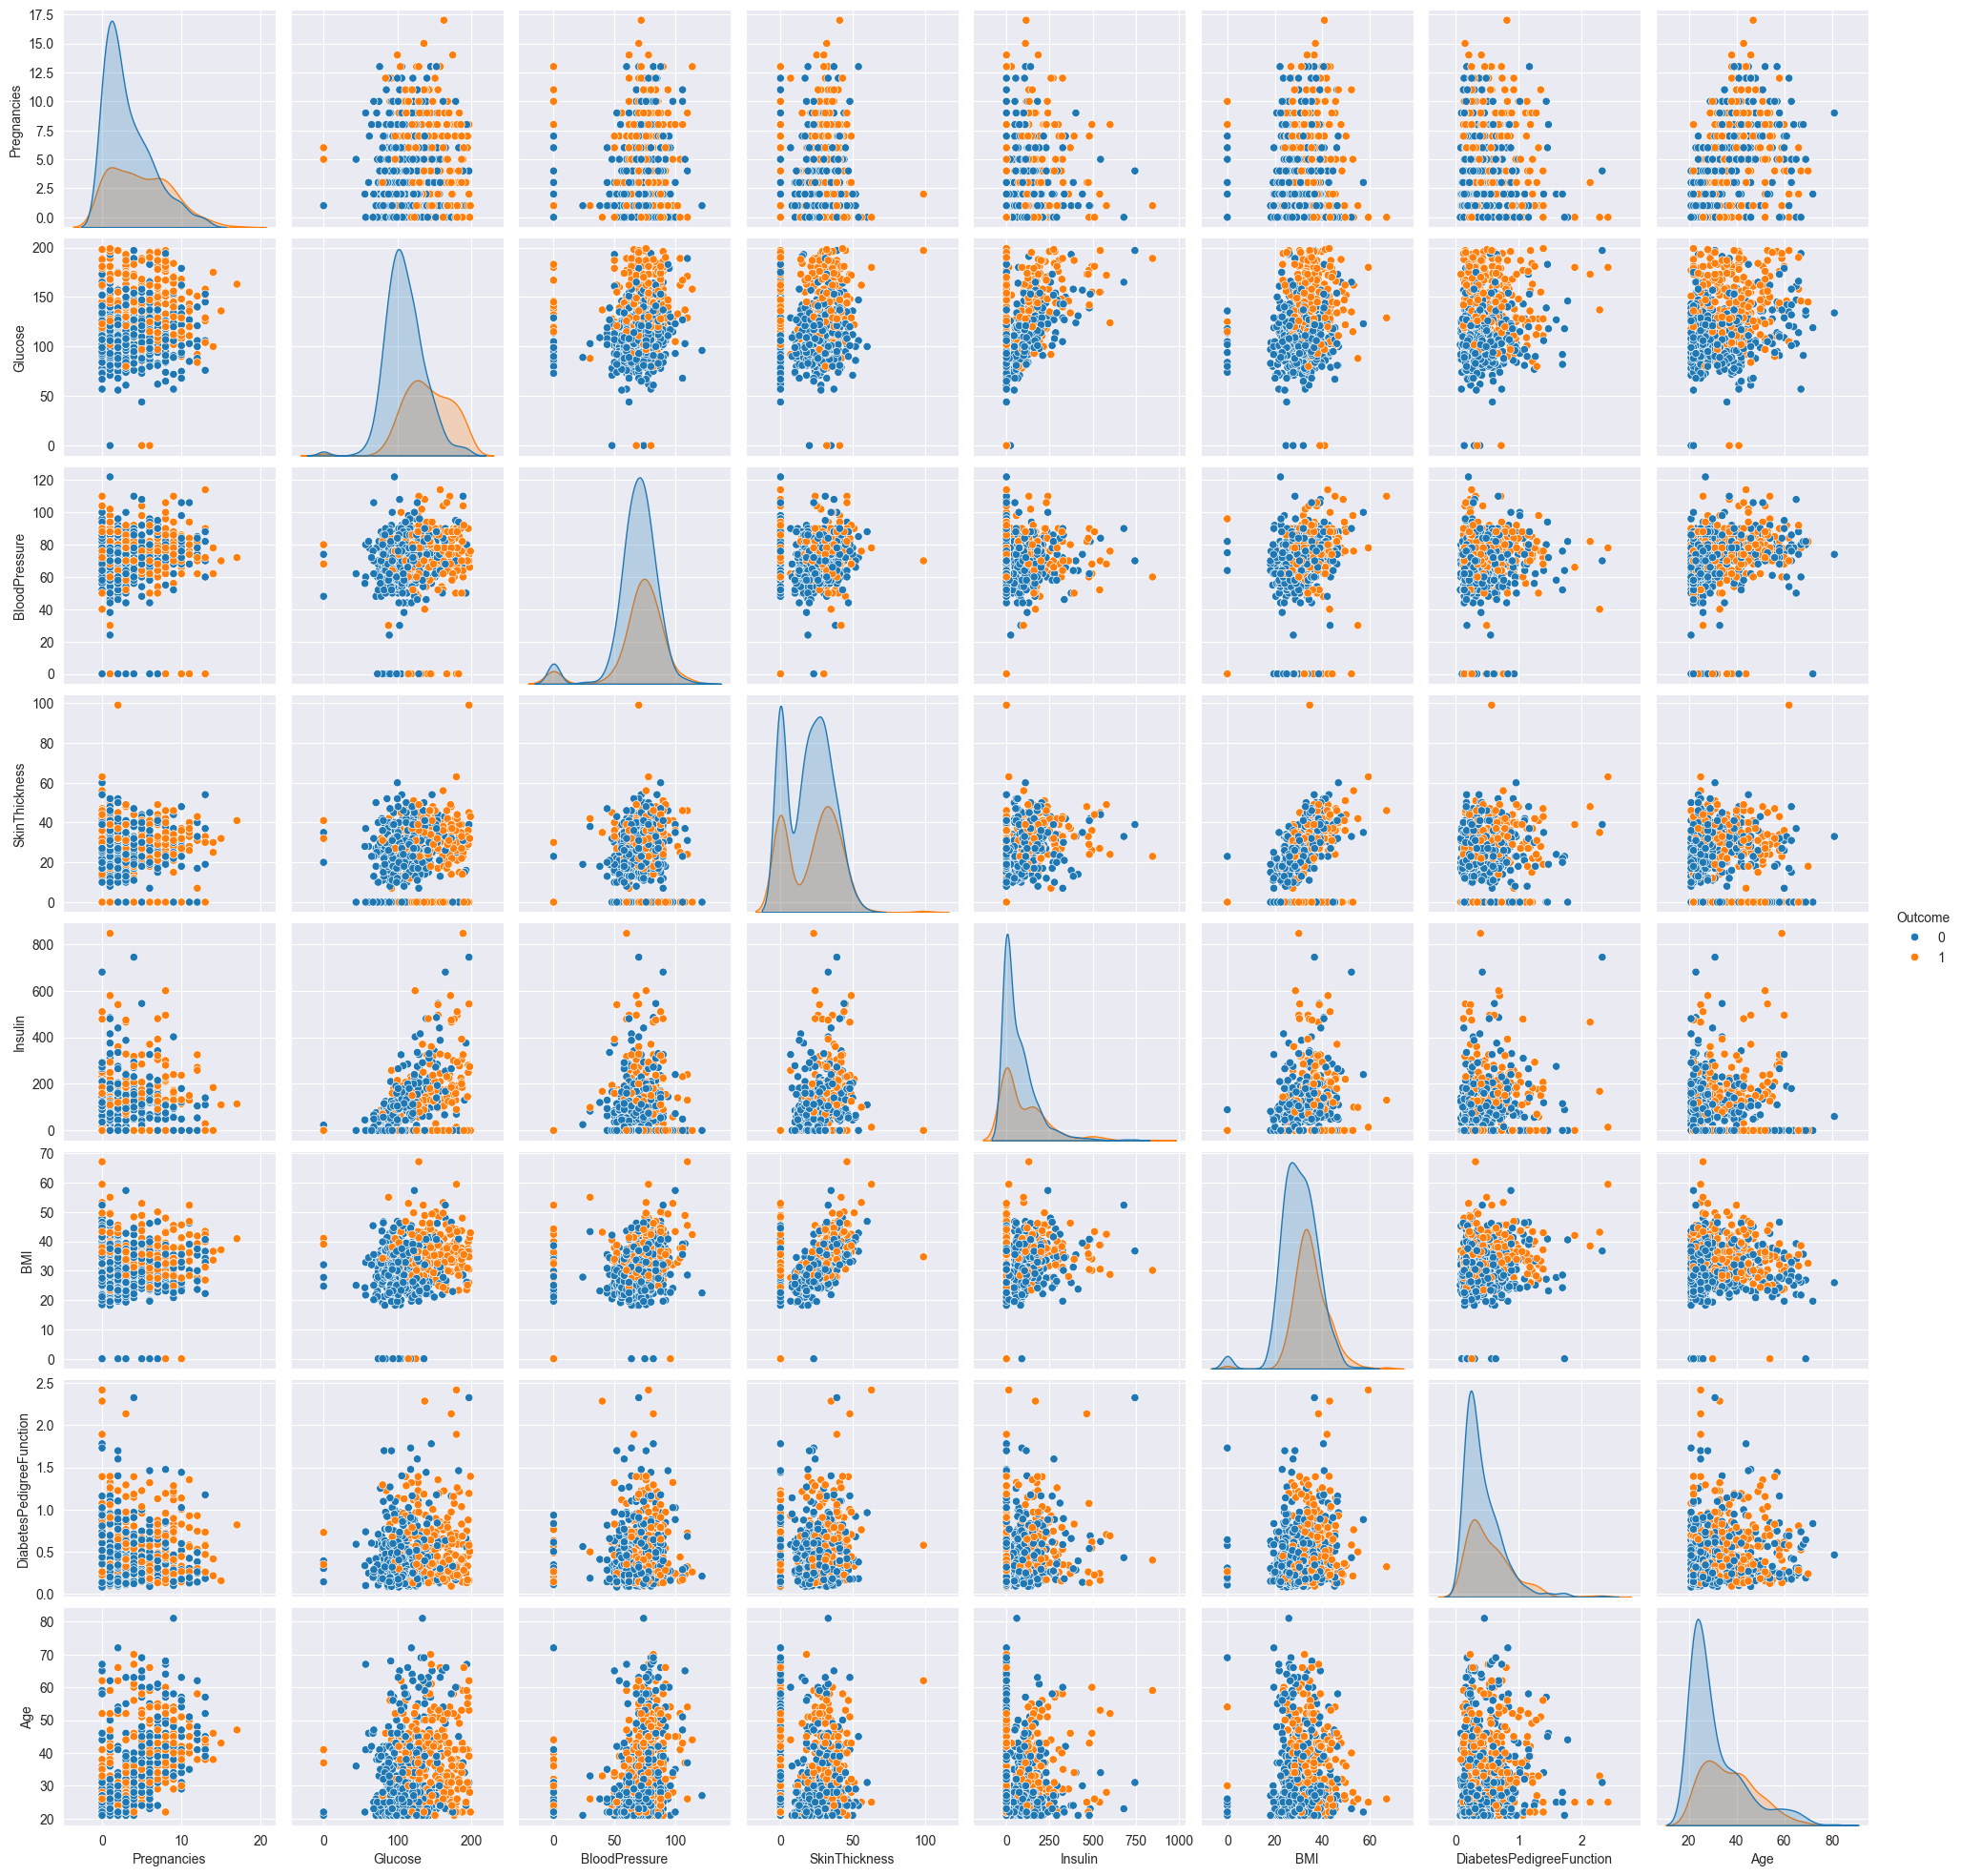

In [2]:
#Plot data as is to check for outliers and areas of particular issue
sns.pairplot(hue = 'Outcome', data = df_all)

In [3]:
#Apply filtering for impossible values
df_filtered = df_all.loc[(df_all['BloodPressure'] >= 40) & (df_all['BMI'] > 10) & (df_all['Insulin'] > 0) & (df_all['Glucose'] > 0)]
print(f"filtered shape is: {df_filtered.shape}")
df_filtered.head()

filtered shape is: (388, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
6,3,78,50,32,88,31.0,0.248,26,1
8,2,197,70,45,543,30.5,0.158,53,1
13,1,189,60,23,846,30.1,0.398,59,1


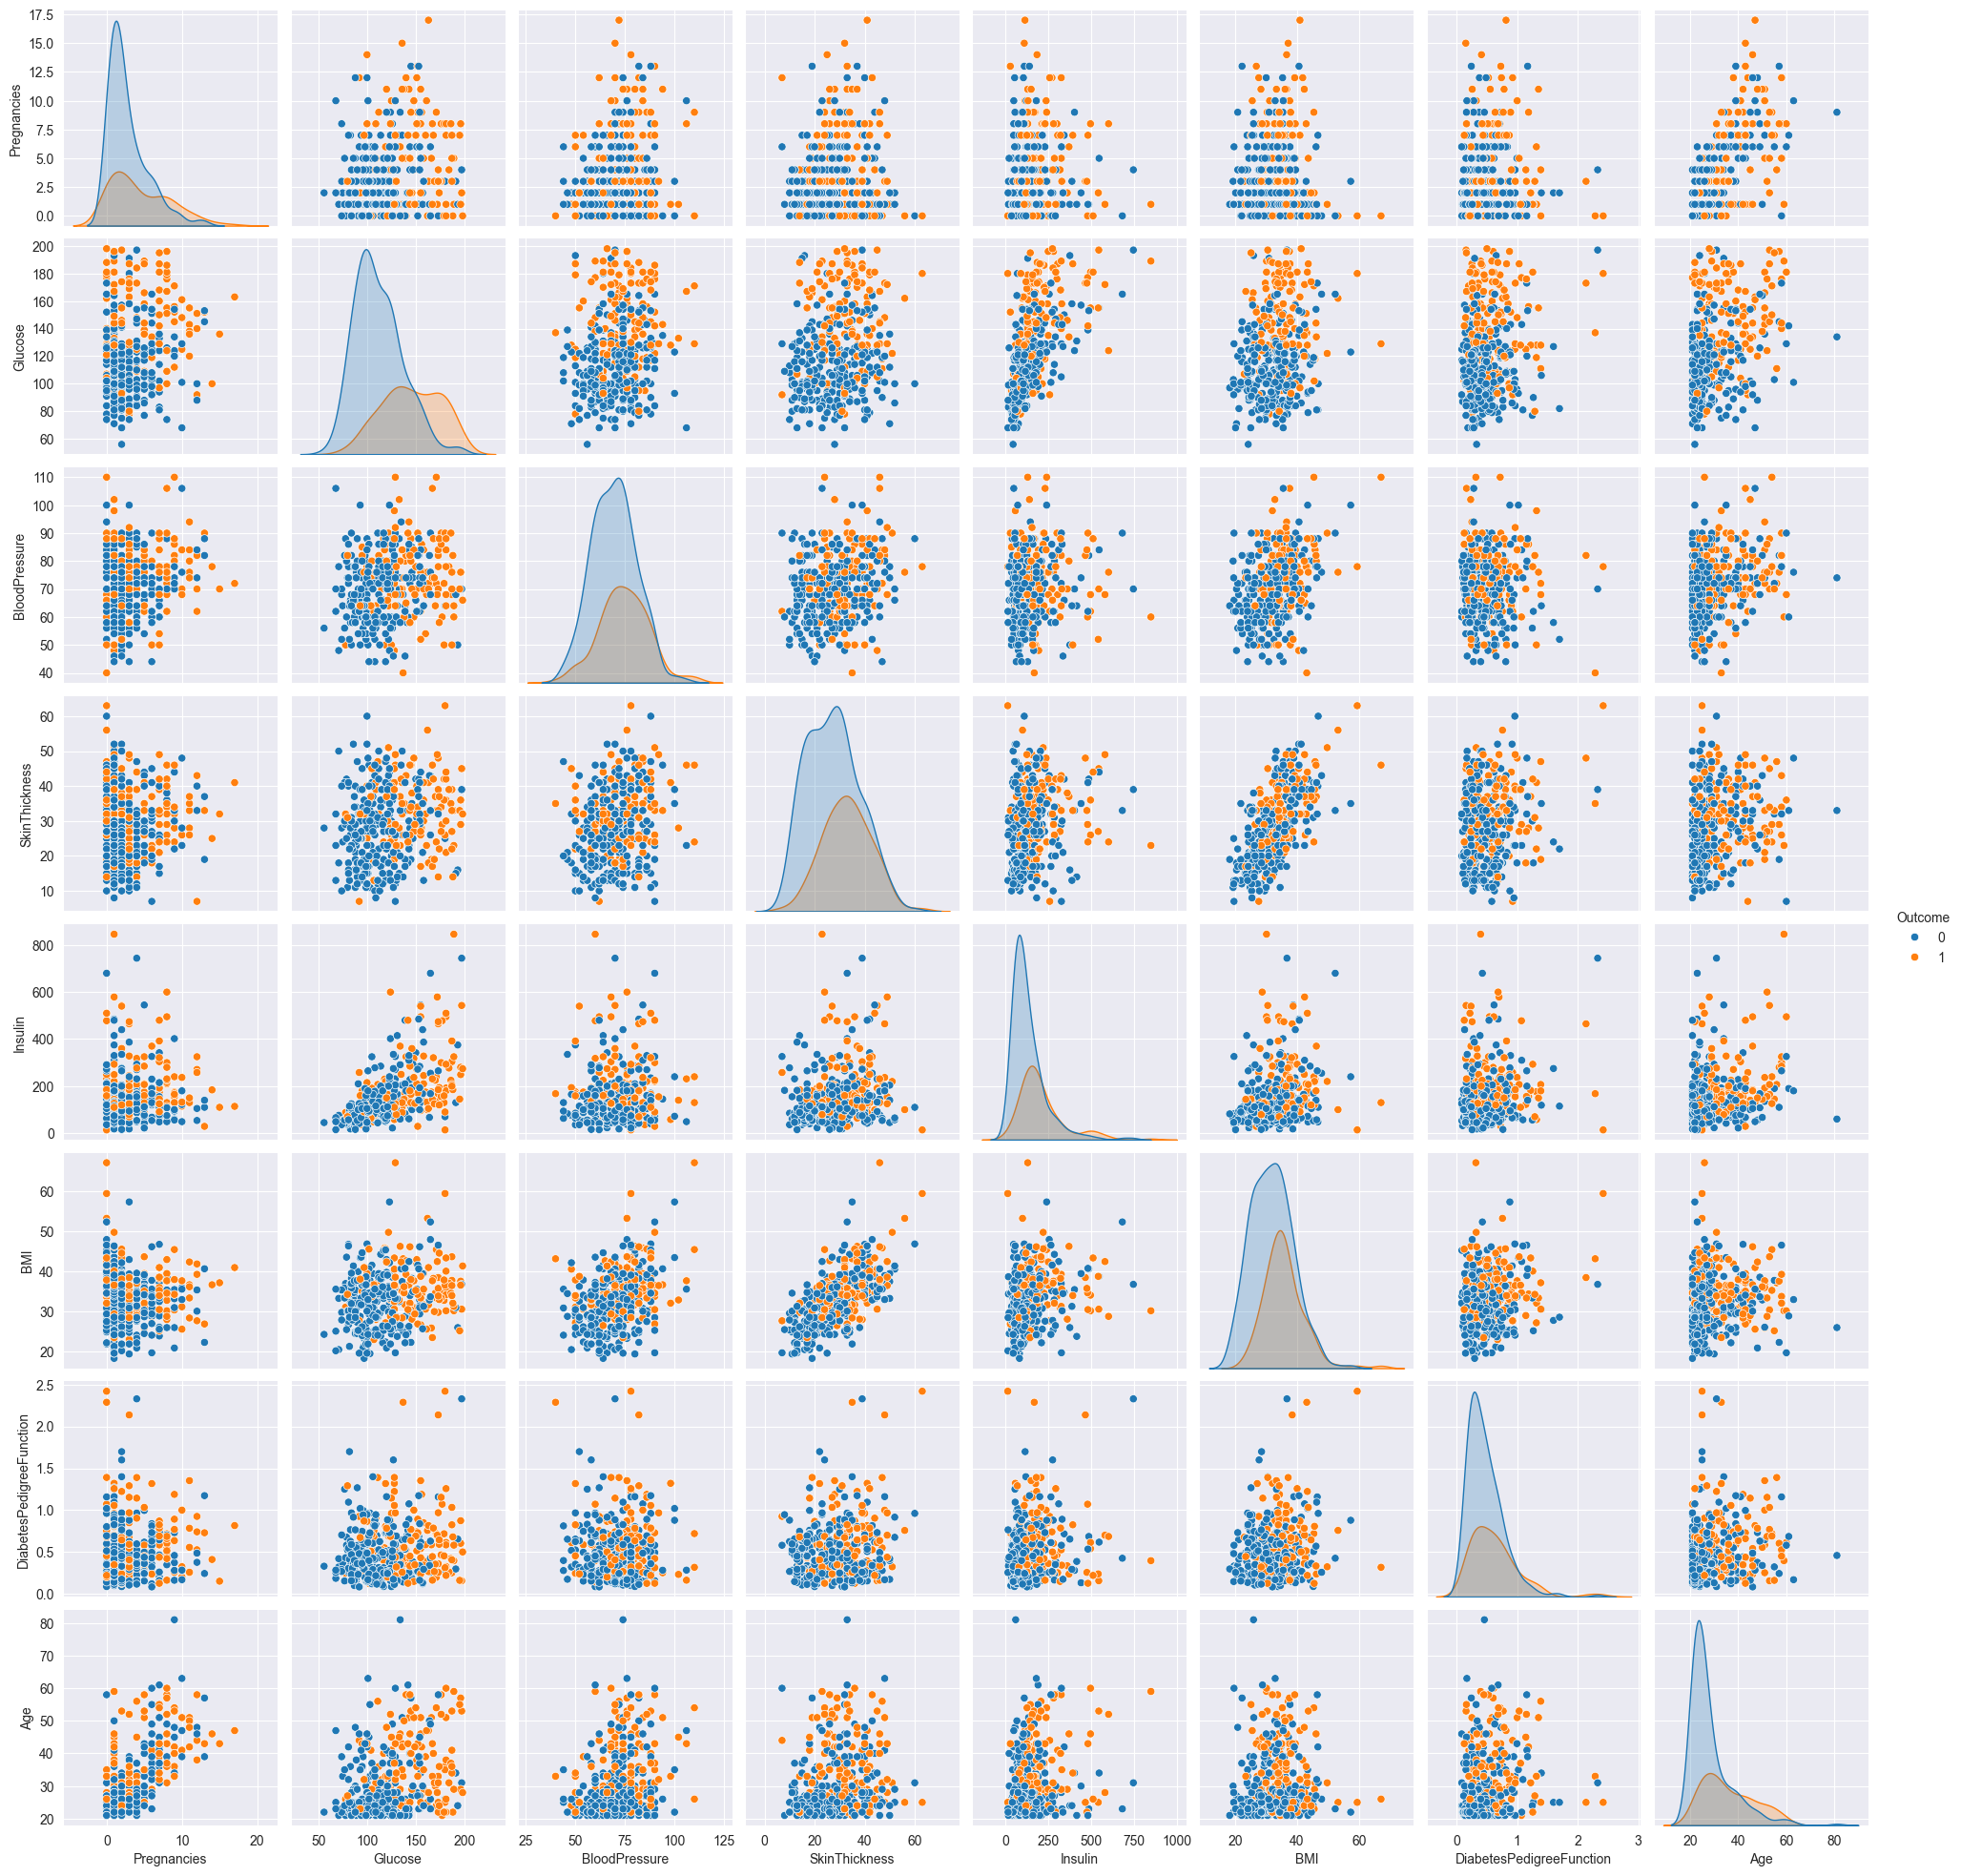

In [4]:
sns.pairplot(hue = 'Outcome', data = df_filtered)

In [9]:
#Split into predictor, classifers and then into test and train
df_class = df_all['Outcome']
print(f"Class Shape is: {df_class.shape}")
df_predict = df_all.drop(['Outcome'], axis=1)
print(f"Predict shape is: {df_predict.shape}")
predict_train, predict_test, class_train, class_test = train_test_split(df_predict, df_class, test_size=0.2, random_state=1, stratify=df_class)
print(f"Predict Train shape is: {predict_train.shape} Predict Test shape is: {predict_test.shape} Class Train shape is: {class_train.shape} Class Test shape is: {class_test.shape}")

Class Shape is: (768,)
Predict shape is: (768, 8)
Predict Train shape is: (614, 8) Predict Test shape is: (154, 8) Class Train shape is: (614,) Class Test shape is: (154,)


In [14]:
#create random forest classifier
rfclf = RandomForestClassifier()
#Fit to training
rfclf.fit(predict_train, class_train)

print(f" rfclf test is {rfclf.score(predict_test, class_test)} train is {rfclf.score(predict_train, class_train)}")

score = f1_score(class_test, rfclf.predict(predict_test), average='macro')
print(f" F1 score is {score}")

 rfclf test is 0.7402597402597403 train is 1.0
 F1 score is 0.6900161030595813
